In [3]:
import pandas as pd

fear_greed = pd.read_csv('fear_greed_index.csv')
trades = pd.read_csv('historical_data.csv')

print(fear_greed.head())
print(trades.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50 

In [4]:
print("FEAR & GREED DATA")
print(fear_greed.shape)
print(fear_greed.columns.tolist())
print(fear_greed['classification'].value_counts())

print("\nTRADES DATA")
print(trades.shape)
print(trades.columns.tolist())

FEAR & GREED DATA
(2644, 4)
['timestamp', 'value', 'classification', 'date']
classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64

TRADES DATA
(211224, 16)
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


In [5]:
fear_greed['date'] = pd.to_datetime(fear_greed['date'])

trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M')
trades['date'] = trades['Timestamp IST'].dt.normalize()

print(fear_greed['date'].head())
print(trades['date'].head())

0   2018-02-01
1   2018-02-02
2   2018-02-03
3   2018-02-04
4   2018-02-05
Name: date, dtype: datetime64[ns]
0   2024-12-02
1   2024-12-02
2   2024-12-02
3   2024-12-02
4   2024-12-02
Name: date, dtype: datetime64[ns]


In [6]:
# Create a lookup: for each date, what was the sentiment?
sentiment_lookup = fear_greed.set_index('date')['classification']

# Attach it to every trade based on that trade's date
trades['classification'] = trades['date'].map(sentiment_lookup)

# Check how many trades got a sentiment label successfully
print(trades['classification'].value_counts())
print("\nTrades with NO sentiment match:", trades['classification'].isna().sum())

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

Trades with NO sentiment match: 6


In [7]:
# Group all trades by sentiment, and calculate key numbers for each group
summary = trades.groupby('classification').agg(
    number_of_trades=('Closed PnL', 'size'),
    total_profit=('Closed PnL', 'sum'),
    avg_profit_per_trade=('Closed PnL', 'mean'),
    win_rate=('Closed PnL', lambda x: (x > 0).mean() * 100)
)

print(summary)

                number_of_trades  total_profit  avg_profit_per_trade  \
classification                                                         
Extreme Fear               21400  7.391102e+05             34.537862   
Extreme Greed              39992  2.715171e+06             67.892861   
Fear                       61837  3.357155e+06             54.290400   
Greed                      50303  2.150129e+06             42.743559   
Neutral                    37686  1.292921e+06             34.307718   

                 win_rate  
classification             
Extreme Fear    37.060748  
Extreme Greed   46.494299  
Fear            42.076750  
Greed           38.482794  
Neutral         39.699093  


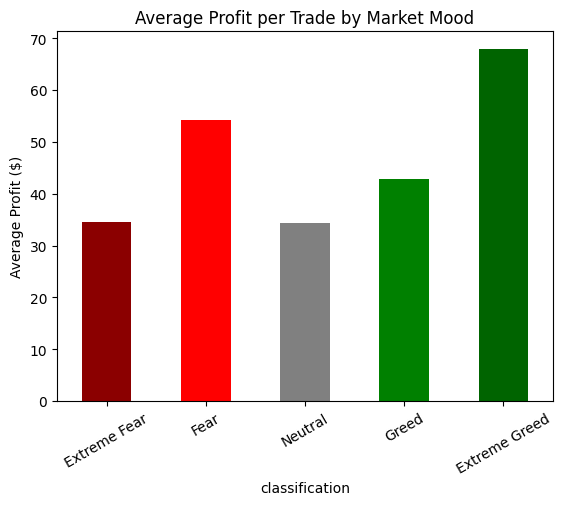

In [8]:
import matplotlib.pyplot as plt

order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
summary_ordered = summary.reindex(order)

summary_ordered['avg_profit_per_trade'].plot(kind='bar', color=['darkred','red','gray','green','darkgreen'])
plt.title('Average Profit per Trade by Market Mood')
plt.ylabel('Average Profit ($)')
plt.xticks(rotation=30)
plt.show()

In [9]:
# Was each trade a "Long" bet (price will go up) or "Short" bet (price will go down)?
trades['side_bias'] = trades['Direction'].apply(
    lambda x: 'Long' if 'Long' in str(x) else ('Short' if 'Short' in str(x) else 'Other')
)

# For each mood, what % of trades were "Long"?
long_pct = trades.groupby('classification')['side_bias'].apply(lambda x: (x == 'Long').mean() * 100)
long_pct = long_pct.reindex(order)

print(long_pct)

classification
Extreme Fear     61.948598
Fear             56.788007
Neutral          53.712254
Greed            32.962249
Extreme Greed    33.766753
Name: side_bias, dtype: float64


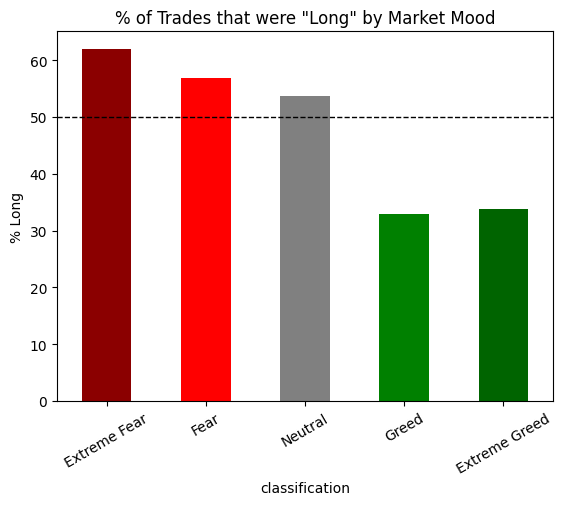

In [11]:
long_pct.plot(kind='bar', color=['darkred','red','gray','green','darkgreen'])
plt.title('% of Trades that were "Long" by Market Mood')
plt.ylabel('% Long')
plt.xticks(rotation=30)
plt.axhline(50, color='black', linestyle='--', linewidth=1)
plt.show()

# Trader Performance vs Bitcoin Market Sentiment

**Objective:** Explore whether Bitcoin market sentiment (Fear/Greed) relates to how Hyperliquid traders perform and behave.

**Method:** Merged 211,224 trades with daily Fear & Greed Index labels by matching each trade's date to that day's sentiment. Grouped trades by sentiment and compared profit, win rate, and long/short positioning.

**Findings:**

1. Traders do slightly better in Greed than Fear. Extreme Greed has the highest average profit per trade ($67.89) and highest win rate (46.5%). Extreme Fear has the lowest win rate (37.1%).

2. The strongest pattern: positioning flips completely with mood. About 58-62% of trades are "Long" (betting price goes up) during Fear, but only about 33% are Long during Greed. Traders in this data behave like contrarians — buying into fear, and shorting into greed.

**Insight for a trading strategy:** Market sentiment predicts trader *behavior* (whether they go long or short) much more strongly than it predicts *profit*. A strategy could use sentiment as a signal for expected crowd positioning, but shouldn't rely on sentiment alone to predict returns.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
